In [1]:
print("Test")

Test


In [2]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words= open('names.txt','r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])


32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos= {i:s for s,i in stoi.items()}
vocab_size=len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
import random
random.seed(42)
random.shuffle(words)

In [6]:
# build the dataset
block_size=8
def build_dataset(words):
    X,Y =[],[]
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context=context[1:]+ [ix]
    X= torch.tensor(X)
    Y=torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y

n1= int(0.8*len(words))
n2=int(0.9*len(words))
Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev=build_dataset(words[n1:n2])
Xte,Yte= build_dataset(words[n2:])


torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [7]:
for x, y in zip(Xtr[:20],Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), "---->",itos[y.item()])

........ ----> y
.......y ----> u
......yu ----> h
.....yuh ----> e
....yuhe ----> n
...yuhen ----> g
..yuheng ----> .
........ ----> d
.......d ----> i
......di ----> o
.....dio ----> n
....dion ----> d
...diond ----> r
..diondr ----> e
.diondre ----> .
........ ----> x
.......x ----> a
......xa ----> v
.....xav ----> i
....xavi ----> e


In [51]:

# -------------------------------------------------------------------------------------------------------
class  Linear:
    def __init__(self,fan_in,fan_out,bias=True):
        self.weight=torch.randn((fan_in,fan_out))/ fan_in**0.5 # Kaiming initialization
        self.bias = torch.zeros(fan_out) if bias else None
    def __call__(self,x):
        self.out= x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight]+([] if self.bias is None else [self.bias])
    
# -----------------------------------------------------------------------------------------------------
class BatchNorm1d:
    def __init__(self,dim,eps=1e-5, momentum=0.1):
        self.eps=eps
        self.momentum = momentum
        self.training= True
        # Parameters (trained with backprop
        self.gamma =torch.ones(dim)
        self.beta= torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean= torch.zeros(dim)
        self.running_var= torch.ones(dim)

    def __call__(self,x):
        # calculating the foward pass 
        if self.training:
            if x.ndim==2:
                dim=0
            elif x.ndim==3:
                dim=(0,1)
            xmean=x.mean(dim, keepdim=True) # batch mean 
            xvar=x.var(dim,keepdim=True) #batch variance

        else:
            xmean=self.running_mean
            xvar=self.running_var
        xhat=(x-xmean)/torch.sqrt(xvar + self.eps)
        self.out=self.gamma * xhat +self.beta
        # Update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean=(1-self.momentum) * self.running_mean +self.momentum * xmean
                self.running_var = (1-self.momentum) * self.running_var + self.momentum *xvar
        return self.out
    def parameters(self):
        return [self.gamma,self.beta]
    
# -------------------------------------------------------------------------------------------------------

class Tanh:
    def __call__(self,x):
        self.out= torch.tanh(x)
        return self.out
    def parameters(self):
        return []
    
# -------------------------------------------------------------------------------------------------------
class Embedding:
    def __init__(self,num_embeddings,embedding_dim):
        self.weight= torch.randn((num_embeddings, embedding_dim))
    
    def __call__(self,IX):
        self.out=self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    
# -------------------------------------------------------------------------------------------------------
class FlattenConsecutive:
    def __init__(self,n):
        self.n=n
    def __call__(self,x):
        B,T,C = x.shape
        x=x.view(B,T//self.n,C*self.n)
        if x.shape[1]==1:
            x= x.squeeze(1)
        self.out=x
        return self.out

    # def __call__(self,x):
    #     self.out= x.view(x.shape[0], -1)
    #     return self.out
    
    def parameters(self):
        return []
    

# -------------------------------------------------------------------------------------------------------
class Sequential:
    def __init__(self,layers):
        self.layers=layers

    def __call__(self,x):
        for layer in self.layers:
            x=layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        # get parameters of all layer and stretch them out into one list 
        return [p for layer in self.layers for p in layer.parameters()]
    

In [52]:
8/2

4.0

In [10]:
torch.manual_seed(42)

In [64]:
n_embd=24 # dimensionality of the character embedding vectors 
n_hidden = 128 #nummber of neurons in the hidden layer of the MLP


model =Sequential([
    Embedding(vocab_size,n_embd),
    FlattenConsecutive(2),Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2),Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2),Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

# Parameter init
with torch.no_grad():
    model.layers[-1].weight *= 0.1 # last layer make less confident

parameters =model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad= True

76579


In [54]:
ix=torch.randint(0, Xtr.shape[0], (4,))
Xb,Yb = Xtr[ix],Ytr[ix]
logits=model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[11,  1, 19, 19,  9,  1, 14,  9],
        [ 0,  0,  0,  2, 18,  1, 19,  9],
        [ 0,  0,  0,  0, 19,  5,  2,  1],
        [ 0,  0,  0,  0,  0,  0,  0,  0]])

In [36]:
for layer in model.layers:
    print(layer.__class__.__name__, ":", tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 68)
BatchNorm1d : (4, 4, 68)
Tanh : (4, 4, 68)
FlattenConsecutive : (4, 2, 136)
Linear : (4, 2, 68)
BatchNorm1d : (4, 2, 68)
Tanh : (4, 2, 68)
FlattenConsecutive : (4, 136)
Linear : (4, 68)
BatchNorm1d : (4, 68)
Tanh : (4, 68)
Linear : (4, 27)


In [37]:
e=torch.randn(32,4,68)
emean=e.mean((0,1),keepdim=True)
evar=e.var(0,keepdim=True)
ehat=(e-emean)/torch.sqrt(evar+1e-5)
ehat.shape

torch.Size([32, 4, 68])

In [38]:
emean.shape

torch.Size([1, 1, 68])

In [57]:
model.layers[3].running_mean.shape

torch.Size([1, 1, 68])

In [40]:
logits.shape

torch.Size([4, 27])

In [41]:
model.layers[0].out.shape # output of Embedding layer

torch.Size([4, 8, 10])

In [42]:
model.layers[1].out.shape # output of Flatten layer

torch.Size([4, 4, 20])

In [56]:
model.layers[2].out.shape #output of Linear layer

torch.Size([32, 4, 68])

In [44]:
(torch.randn(4,7,80) @ torch.randn(80,200)+ torch.randn(200)).shape

torch.Size([4, 7, 200])

In [45]:
list(range(10))[1::2]

[1, 3, 5, 7, 9]

In [46]:
e=torch.randn(4,8,10) # goal: want this to be (4,4,20) where consecutive 10-d vectors get concatenated
explicit=torch.cat([e[:, ::2, :], e[:, 1::2, :]],dim=2)
explicit.shape

torch.Size([4, 4, 20])

In [47]:
(e.view(4,4,20)==explicit).all()

tensor(True)

In [65]:
# same optimizationas the last time
max_steps = 200000
batch_size=32
lossi=[]

for i in range(max_steps):
    # minibatch construct 
    ix= torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb,Yb=Xtr[ix], Ytr[ix] # batch X,Y

    # foward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits,Yb) # loss function



    # x= Xb
    # for layer in layers:
    #     x = layer(x)
    # loss = F.cross_entropy(x,Yb) #loss function

    # backward pass 
    for p in parameters:
        p.grad= None
    loss.backward()

    # update: simple SGD
    lr=0.1 if i < 150000 else 0.01 #step learning rate decay 
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 ==0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    # break|

      0/ 200000: 3.2991
  10000/ 200000: 2.5956
  20000/ 200000: 2.4793
  30000/ 200000: 1.9331
  40000/ 200000: 1.7069
  50000/ 200000: 1.9367
  60000/ 200000: 2.2168
  70000/ 200000: 2.3746
  80000/ 200000: 1.8843
  90000/ 200000: 1.8452
 100000/ 200000: 2.0480
 110000/ 200000: 1.9256
 120000/ 200000: 1.7802
 130000/ 200000: 1.9988
 140000/ 200000: 2.0705
 150000/ 200000: 1.6311
 160000/ 200000: 1.9876
 170000/ 200000: 2.1223
 180000/ 200000: 1.6747
 190000/ 200000: 2.1383


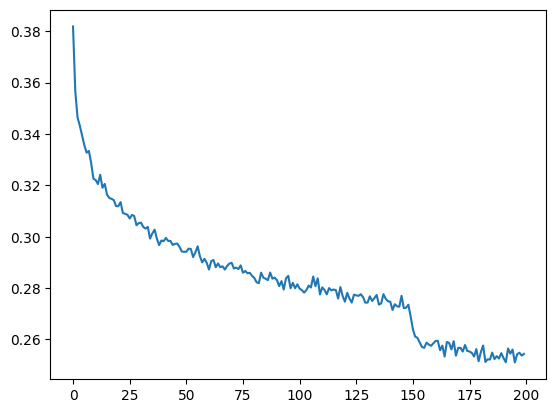

In [66]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [67]:
torch.tensor(lossi).view(-1,1000).mean(1)

tensor([0.3819, 0.3567, 0.3464, 0.3433, 0.3394, 0.3356, 0.3327, 0.3334, 0.3288,
        0.3226, 0.3221, 0.3205, 0.3241, 0.3191, 0.3206, 0.3164, 0.3151, 0.3147,
        0.3143, 0.3119, 0.3119, 0.3135, 0.3093, 0.3089, 0.3086, 0.3071, 0.3085,
        0.3081, 0.3045, 0.3053, 0.3055, 0.3038, 0.3032, 0.3038, 0.2993, 0.3013,
        0.3028, 0.2993, 0.2967, 0.2985, 0.2983, 0.2995, 0.2984, 0.2984, 0.2968,
        0.2972, 0.2973, 0.2961, 0.2943, 0.2941, 0.2941, 0.2954, 0.2952, 0.2921,
        0.2939, 0.2963, 0.2924, 0.2900, 0.2914, 0.2899, 0.2872, 0.2905, 0.2910,
        0.2881, 0.2896, 0.2881, 0.2885, 0.2872, 0.2886, 0.2895, 0.2898, 0.2876,
        0.2880, 0.2874, 0.2888, 0.2860, 0.2867, 0.2858, 0.2860, 0.2848, 0.2840,
        0.2823, 0.2819, 0.2860, 0.2841, 0.2837, 0.2831, 0.2861, 0.2837, 0.2841,
        0.2831, 0.2808, 0.2827, 0.2794, 0.2838, 0.2848, 0.2799, 0.2820, 0.2800,
        0.2815, 0.2798, 0.2792, 0.2782, 0.2792, 0.2810, 0.2802, 0.2845, 0.2807,
        0.2838, 0.2775, 0.2803, 0.2793, 

In [68]:
torch.arange(10).view(-1,5)

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [69]:
# Put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
    layer.training=False

In [70]:
# evaluate the loss 
@torch.no_grad() # this decorator disables gradient tracking inside pytorch 
def split_loss(split):
    x,y ={
        "train":(Xtr,Ytr),
        'val':(Xdev,Ydev),
        'test':(Xte,Yte),
    }[split]
    logits= model(x)
    loss = F.cross_entropy(logits,y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.770820140838623
val 1.9908993244171143


#### Perfomance Log
Original(3 characters context + 200 hidden neurons ,12k params): train: 2.1326 , val: 2.336

Context: 3-> 8 (22k params): train: 1.8862, val: 2.0456 

fixing the BNbug train:1.9093 , val: 2.0113

adding n_hidden : 24 and n_input :128 train: 1.7708 test: 1.9909

In [28]:
#  sample from the model
for _ in range(20):
    out=[]
    context =[0] * block_size
    while True:
        # foward pass the neural net
        logits= model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        # sample from the distribution 
        ix= torch.multinomial(probs, num_samples=1).item()
        # shift the context window and track the samples
        context= context[1:]+ [ix]
        out.append(ix)
        # if we sample the special '.' token , break
        if ix == 0:
            break

    print(''.join(itos[i] for i in out)) # decode and print the generated word

rihett.
amarlus.
jednol.
aliven.
aluwande.
hya.
osodesdo.
dallis.
rahque.
kerree.
mosselle.
kulton.
aseyas.
vali.
jassielle.
amrae.
devon.
aimi.
kenick.
poltory.
